# Notebook 1 — Analisi Prestazioni K-Fold

Valutazione sistematica di **Baseline CLAP** vs **ResiDual CLAP** su più dataset,
usando K-Fold stratificato per una stima robusta dell'accuracy.

**Pipeline per ogni dataset:**
1. Carica il dataset
2. Se il dataset supera `MAX_DATASET_SIZE`, campionamento stratificato riproducibile
3. Per ogni fold: split train/test stratificato
4. Baseline: valuta CLAP standard sul test fold
5. Residual: fitta PCA sul train fold → valuta sul test fold
6. Aggrega risultati → plot comparativi

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES (solo prima volta su Kaggle)
# ============================================================
#!pip install scikit-optimize --quiet

In [4]:
# ============================================================
# IMPORTS
# ============================================================
import sys
import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from models.residual_clap_utils import (
    KFoldEvaluator,
    get_dataset_registry,
    plot_kfold_results,
)

print("✅ Import completati")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Import completati
Device: cpu


In [12]:
# ============================================================
# CONFIGURAZIONE GLOBALE
# ============================================================

# --- Parametri K-Fold ---
N_SPLITS     = 5       # Numero di fold
PCA_SAMPLES  = 200     # Campioni per fitting PCA (per fold)
TEST_SIZE    = None    # Campioni di test per fold (None = usa tutti)
CLAP_VERSION = '2023'  # '2022' o '2023'
RANDOM_STATE = 42

# --- Limite dimensione dataset ---
# Se un dataset ha più campioni di MAX_DATASET_SIZE, viene eseguito un
# campionamento stratificato riproducibile prima di formare i fold.
# Impostare a None per non applicare nessun limite.
MAX_DATASET_SIZE = 2000  # es. 500 | None

# --- Soppressione output modelli interni ---
# Se True, sopprime stdout e stderr generati dai modelli caricati
# internamente da KFoldEvaluator (incluso output nativo C/C++).
# Utile per tenere il log del notebook pulito.
# Impostare a False per il debug.
SUPPRESS_MODEL_PRINTS = True

# --- Configurazione ResiDual (punto di partenza) ---
RESIDUAL_CONFIG = {
    'mode': 'attention',
    'n_components_ratio': 0.15,
    'whitening_strength': 1.0,
    'whitening_eps': 1e-6,
    'target_layers': [3],
}

# --- Dataset da valutare ---
# Specifica qui quali dataset vuoi testare e il loro root path
DATASETS_TO_EVAL = {
    'ESC50':      '../data',
    'VocalSound': '../data',
    'TinySOL':    '../data',
    'IRMAS':      '../data',
}

# Prompt testuale per la classificazione
PROMPT = 'this is the sound of '

print("Configurazione caricata:")
print(f"  N_SPLITS:             {N_SPLITS}")
print(f"  PCA_SAMPLES:          {PCA_SAMPLES}")
print(f"  TEST_SIZE:            {TEST_SIZE}")
print(f"  MAX_DATASET_SIZE:     {MAX_DATASET_SIZE}")
print(f"  SUPPRESS_MODEL_PRINTS:{SUPPRESS_MODEL_PRINTS}")
print(f"  CLAP_VERSION:         {CLAP_VERSION}")
print(f"  RANDOM_STATE:         {RANDOM_STATE}")
print(f"  Config:               {RESIDUAL_CONFIG}")

Configurazione caricata:
  N_SPLITS:             5
  PCA_SAMPLES:          200
  TEST_SIZE:            None
  MAX_DATASET_SIZE:     2000
  SUPPRESS_MODEL_PRINTS:True
  CLAP_VERSION:         2023
  RANDOM_STATE:         42
  Config:               {'mode': 'attention', 'n_components_ratio': 0.15, 'whitening_strength': 1.0, 'whitening_eps': 1e-06, 'target_layers': [3]}


In [13]:
# ============================================================
# CARICAMENTO DATASET
# ============================================================

DATASET_REGISTRY = get_dataset_registry()
print(f"Dataset disponibili: {list(DATASET_REGISTRY.keys())}")

loaded_datasets = {}

for ds_name, ds_root in DATASETS_TO_EVAL.items():
    if ds_name not in DATASET_REGISTRY:
        print(f"⚠️  {ds_name} non trovato nel registry, skip")
        continue

    print(f"\nCaricamento {ds_name} da {ds_root}...")
    try:
        ds = DATASET_REGISTRY[ds_name](root=ds_root, download=False)
        loaded_datasets[ds_name] = ds
        print(f"  ✅ {ds_name}: {len(ds)} campioni, {len(ds.classes)} classi")
        print(f"     Classi: {ds.classes}")
    except Exception as e:
        print(f"  ❌ Errore caricamento {ds_name}: {e}")

print(f"\nDataset caricati: {list(loaded_datasets.keys())}")

Dataset disponibili: ['ESC50', 'TinySOL', 'VocalSound', 'IRMAS']

Caricamento ESC50 da ../data...
Loading audio files


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:00<00:00, 15237.22it/s]

✓ Cache di validazione trovata (2026-04-01T21:46:58.127961): 2000 validi, 0 corrotti. Skip validazione.
  ✅ ESC50: 2000 campioni, 50 classi
     Classi: ['airplane', 'breathing', 'brushing teeth', 'can opening', 'car horn', 'cat', 'chainsaw', 'chirping birds', 'church bells', 'clapping', 'clock alarm', 'clock tick', 'coughing', 'cow', 'crackling fire', 'crickets', 'crow', 'crying baby', 'dog', 'door wood creaks', 'door wood knock', 'drinking sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass breaking', 'hand saw', 'helicopter', 'hen', 'insects', 'keyboard typing', 'laughing', 'mouse click', 'pig', 'pouring water', 'rain', 'rooster', 'sea waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet flush', 'train', 'vacuum cleaner', 'washing machine', 'water drops', 'wind']

Caricamento VocalSound da ../data...


Loading audio files


...

✓ Cache di validazione trovata (2026-04-02T01:44:11.836275): 20985 validi, 39 corrotti. Skip validazione.
  ✅ VocalSound: 20985 campioni, 6 classi
     Classi: ['cough', 'laughter', 'sigh', 'sneeze', 'sniff', 'throatclearing']

Caricamento TinySOL da ../data...
Loading audio files


100%|██████████| 2913/2913 [00:00<00:00, 15603.36it/s]


✓ Cache di validazione trovata (2026-04-01T23:54:22.189250): 2913 validi, 0 corrotti. Skip validazione.
  ✅ TinySOL: 2913 campioni, 14 classi
     Classi: ['Accordion', 'Bass Tuba', 'Bassoon', 'Clarinet Bb', 'Contrabass', 'Flute', 'Horn', 'Oboe', 'Sax Alto', 'Trombone', 'Trumpet C', 'Viola', 'Violin', 'Violoncello']

Caricamento IRMAS da ../data...
Loading IRMAS audio files...


100%|██████████| 11/11 [00:00<00:00, 36.63it/s]

  Totale campioni caricati: 6705
✓ Cache di validazione trovata (2026-04-09T18:59:59.216527): 6705 validi, 0 corrotti. Skip validazione.
  ✅ IRMAS: 6705 campioni, 11 classi
     Classi: ['cello', 'clarinet', 'flute', 'guitar acoustic', 'guitar electric', 'organ', 'piano', 'saxophone', 'trumpet', 'violin', 'voice']

Dataset caricati: ['ESC50', 'VocalSound', 'TinySOL', 'IRMAS']


In [7]:
# ============================================================
# ESECUZIONE K-FOLD SU TUTTI I DATASET
# ============================================================

all_results = {}

for ds_name, dataset in loaded_datasets.items():
    print(f"\n{'='*70}")
    print(f"DATASET: {ds_name}  ({len(dataset)} campioni, {len(dataset.classes)} classi)")
    print(f"{'='*70}")

    text_labels = [PROMPT + x for x in dataset.classes]

    evaluator = KFoldEvaluator(
        dataset=dataset,
        text_labels=text_labels,
        residual_config=RESIDUAL_CONFIG,
        n_splits=N_SPLITS,
        pca_samples=PCA_SAMPLES,
        test_size=TEST_SIZE,
        max_dataset_size=MAX_DATASET_SIZE,          # ← nuovo parametro
        suppress_model_prints=SUPPRESS_MODEL_PRINTS, # ← nuovo parametro
        clap_version=CLAP_VERSION,
        use_cuda=torch.cuda.is_available(),
        random_state=RANDOM_STATE,
    )

    results = evaluator.run(verbose=True)
    all_results[ds_name] = results

    # Salva risultato parziale per sicurezza
    out_path = f'../results/kfold_{ds_name}.json'
    with open(out_path, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f"\n💾 Risultati salvati in {out_path}")


DATASET: TinySOL  (2913 campioni, 14 classi)
  ⚠️  Dataset ridotto: 2913 → 1994 campioni (max_dataset_size=2000, campionamento stratificato, seed=42)

FOLD 1 / 5
  Train: 1595 campioni | Test: 399 campioni

  [Baseline] Caricamento modello...


  Fold 1 Baseline: 100%|██████████| 399/399 [01:20<00:00,  4.97it/s]


  Baseline accuracy: 0.3358

  [Residual] Caricamento modello...
  [Residual] Fitting PCA su 200 campioni da train split...


  Fold 1 Residual: 100%|██████████| 399/399 [01:27<00:00,  4.55it/s]

  Residual accuracy: 0.3409
  Delta: +0.0050

FOLD 2 / 5
  Train: 1595 campioni | Test: 399 campioni

  [Baseline] Caricamento modello...


...


  Fold 5 Baseline: 100%|██████████| 399/399 [01:32<00:00,  4.33it/s]

  Baseline accuracy: 0.6140

  [Residual] Caricamento modello...


  [Residual] Fitting PCA su 200 campioni da train split...


  Fold 5 Residual: 100%|██████████| 399/399 [01:31<00:00,  4.35it/s]


  Residual accuracy: 0.6115
  Delta: -0.0025

RIEPILOGO K-FOLD
Baseline:  0.6192 ± 0.0139  (folds: ['0.618', '0.624', '0.599', '0.642', '0.614'])
Residual:  0.6253 ± 0.0106  (folds: ['0.625', '0.624', '0.622', '0.644', '0.612'])
Delta:     +0.0060
Campioni effettivi usati: 1996

💾 Risultati salvati in ../results/kfold_IRMAS.json


In [8]:
# ============================================================
# RIEPILOGO TABELLARE
# ============================================================

results_dir = '../results'

all_results = {}

# Carica tutti i file kfold_*.json
for fname in os.listdir(results_dir):
    if fname.startswith('kfold_') and fname.endswith('.json'):
        ds_name = fname.replace('kfold_', '').replace('.json', '')
        path = os.path.join(results_dir, fname)
        
        with open(path, 'r') as f:
            all_results[ds_name] = json.load(f)

# --- Stampa tabella ---
print("\n" + "="*85)
print(f"{'RIEPILOGO FINALE':^85}")
print("="*85)
print(f"{'Dataset':<15} {'N eff':>6} {'Baseline':>10} {'±std':>6} {'Residual':>10} {'±std':>6} {'Delta':>8}")
print("-"*85)

for ds_name, res in all_results.items():
    b = res['baseline']
    r = res['residual']
    delta = res['delta_mean']
    n_eff = res.get('effective_dataset_size', '?')
    
    delta_str = f"{delta:+.4f}"
    
    print(f"{ds_name:<15} {str(n_eff):>6} "
          f"{b['mean']:>10.4f} {b['std']:>6.4f} "
          f"{r['mean']:>10.4f} {r['std']:>6.4f} "
          f"{delta_str:>8}")

print("="*85)


                                  RIEPILOGO FINALE                                   
Dataset          N eff   Baseline   ±std   Residual   ±std    Delta
-------------------------------------------------------------------------------------
ESC50             2000     0.9385 0.0106     0.9280 0.0129  -0.0105
VocalSound        1998     0.7598 0.0182     0.7833 0.0217  +0.0235
TinySOL           1994     0.3200 0.0165     0.3400 0.0259  +0.0200
IRMAS             1996     0.6192 0.0139     0.6253 0.0106  +0.0060


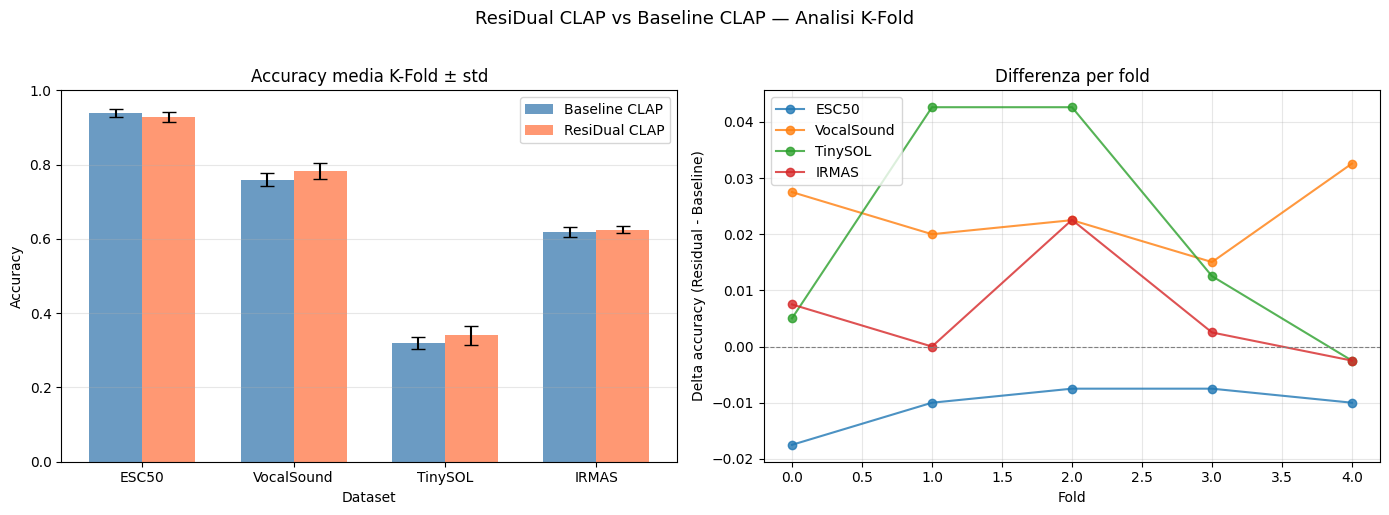

📊 Plot salvato in kfold_comparison.png


In [10]:
# ============================================================
# PLOT COMPARATIVI
# ============================================================

if len(all_results) > 0:
    fig = plot_kfold_results(all_results, figsize=(14, 5))
    plt.suptitle('ResiDual CLAP vs Baseline CLAP — Analisi K-Fold',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../results/kfold_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Plot salvato in kfold_comparison.png")

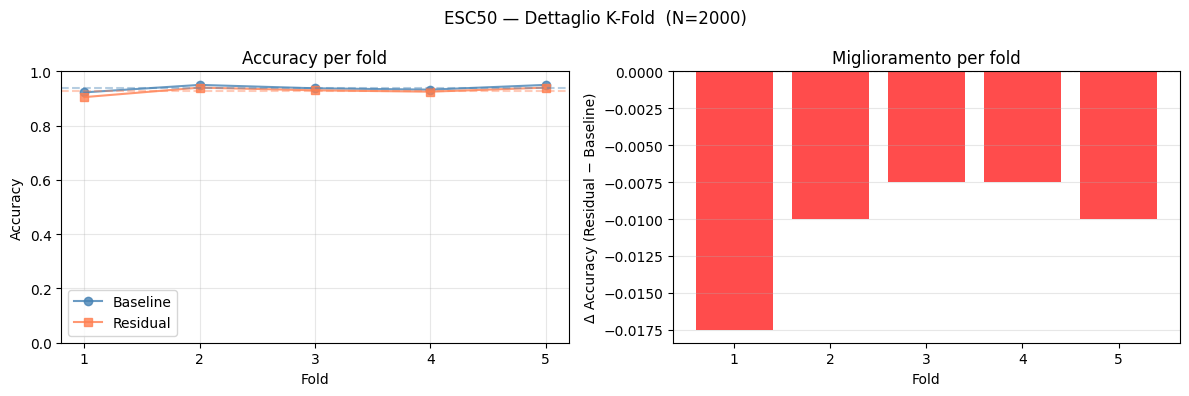

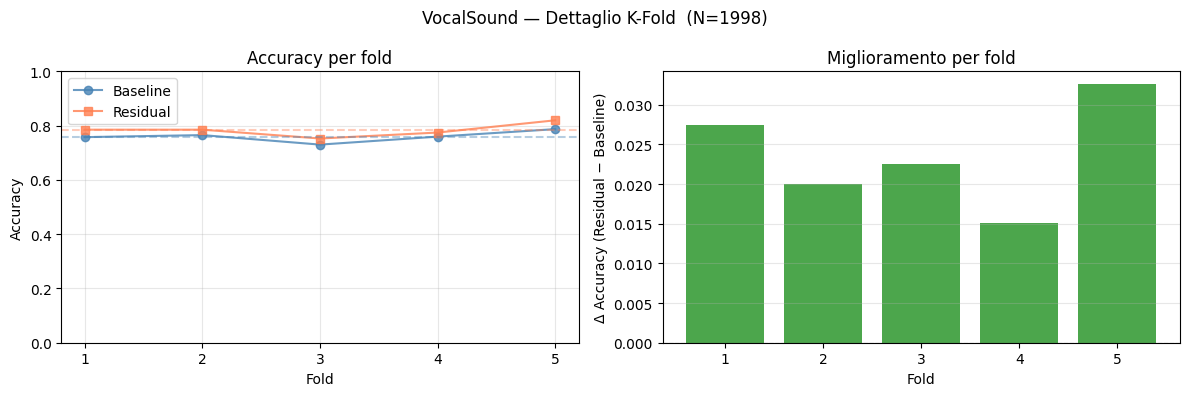

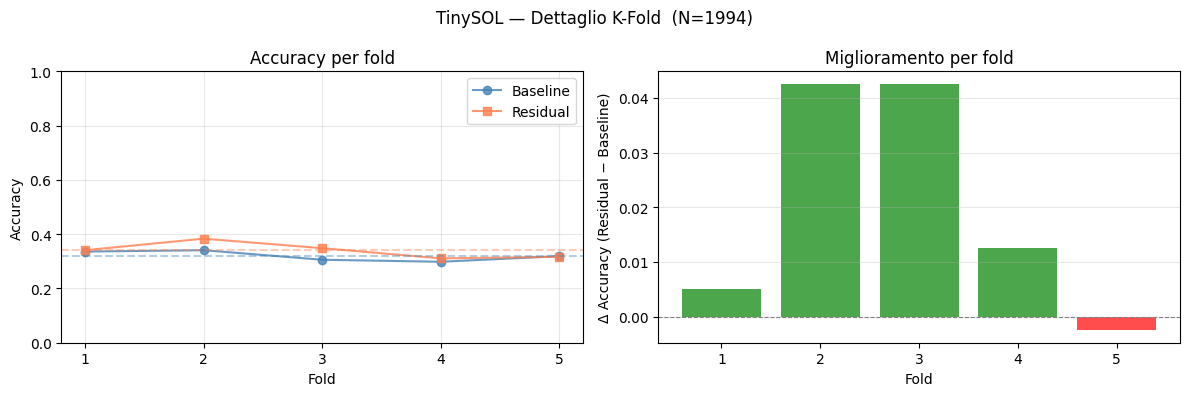

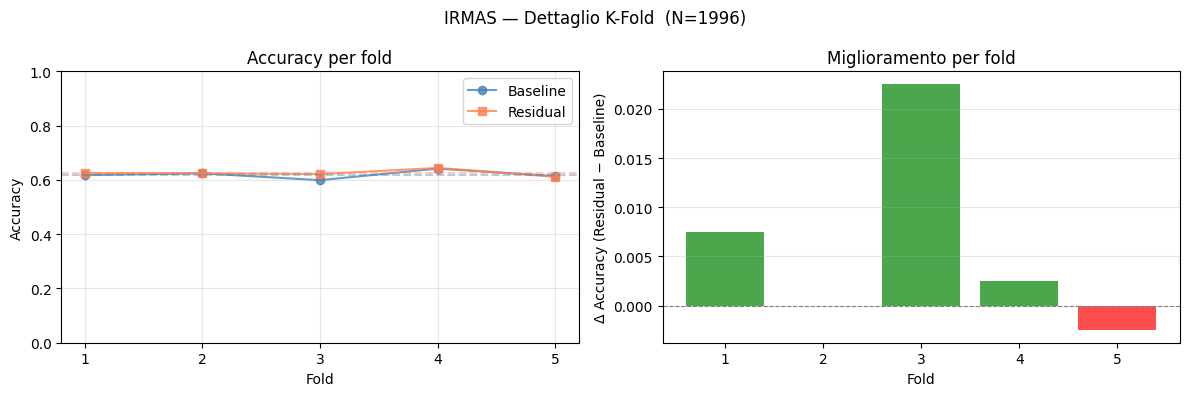

In [14]:
# ============================================================
# PLOT PER-FOLD DETTAGLIATO (per ogni dataset)
# ============================================================

for ds_name, res in all_results.items():
    b_folds = res['baseline']['fold_accs']
    r_folds = res['residual']['fold_accs']
    n_folds = len(b_folds)
    fold_ids = list(range(1, n_folds + 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    n_eff = res.get('effective_dataset_size', len(loaded_datasets[ds_name]))
    fig.suptitle(f'{ds_name} — Dettaglio K-Fold  (N={n_eff})', fontsize=12)

    # Accuracy per fold
    ax = axes[0]
    ax.plot(fold_ids, b_folds, 'o-', color='steelblue', label='Baseline', alpha=0.8)
    ax.plot(fold_ids, r_folds, 's-', color='coral',     label='Residual', alpha=0.8)
    ax.axhline(res['baseline']['mean'], color='steelblue', linestyle='--', alpha=0.4)
    ax.axhline(res['residual']['mean'], color='coral',     linestyle='--', alpha=0.4)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy per fold')
    ax.set_xticks(fold_ids)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

    # Delta per fold
    ax2 = axes[1]
    deltas = [r - b for r, b in zip(r_folds, b_folds)]
    colors = ['green' if d > 0 else 'red' for d in deltas]
    ax2.bar(fold_ids, deltas, color=colors, alpha=0.7)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel('Fold')
    ax2.set_ylabel('Δ Accuracy (Residual − Baseline)')
    ax2.set_title('Miglioramento per fold')
    ax2.set_xticks(fold_ids)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../results/kfold_{ds_name}_detail.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
# ============================================================
# SALVATAGGIO RISULTATI COMPLETI
# ============================================================

with open('../results/kfold_all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print("✅ Tutti i risultati salvati in kfold_all_results.json")
print("\nFile generati:")
for f in Path('results').glob('kfold_*'):
    print(f"  {f.name}")

✅ Tutti i risultati salvati in kfold_all_results.json

File generati:


In [17]:
# ============================================================
# ANALISI STATISTICA (t-test appaiato per fold)
# ============================================================

from scipy import stats

print("\n" + "="*60)
print("ANALISI STATISTICA (t-test appaiato per fold)")
print("="*60)

for ds_name, res in all_results.items():
    b_folds = np.array(res['baseline']['fold_accs'])
    r_folds = np.array(res['residual']['fold_accs'])

    if len(b_folds) < 2:
        print(f"{ds_name}: troppo pochi fold per t-test")
        continue

    t_stat, p_val = stats.ttest_rel(r_folds, b_folds)
    significance = "**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns")

    print(f"\n{ds_name}:")
    print(f"  t-statistic: {t_stat:+.4f}")
    print(f"  p-value:     {p_val:.4f}  ({significance})")
    print(f"  Conclusione: {'Miglioramento significativo' if p_val < 0.05 and t_stat > 0 else ('Peggioramento significativo' if p_val < 0.05 else 'Nessuna differenza significativa')}")


ANALISI STATISTICA (t-test appaiato per fold)

ESC50:
  t-statistic: -5.7155
  p-value:     0.0046  (**)
  Conclusione: Peggioramento significativo

VocalSound:
  t-statistic: +7.7697
  p-value:     0.0015  (**)
  Conclusione: Miglioramento significativo

TinySOL:
  t-statistic: +2.1079
  p-value:     0.1027  (ns)
  Conclusione: Nessuna differenza significativa

IRMAS:
  t-statistic: +1.3494
  p-value:     0.2485  (ns)
  Conclusione: Nessuna differenza significativa
